# Alcohol Language Corpus (ALC) Exploratory Data Analysis

Things to investigate
- distribution of data samples w.r.t
    - session
    - prompt
- the alcohol habit distribution
- br-ac & bl-ac distributions
- br-ac & bl-ac correlation

In [2]:
import os
import json
import opensmile
import numpy as np
import pandas as pd
import os.path as osp
import matplotlib.pyplot as plt


In [3]:
ROOT_DIR = osp.join("data","ALC")
METADATA_DIR = osp.join(ROOT_DIR,"metadata")
TABLE_DIR = osp.join(METADATA_DIR,"CLARINDocu","TABLE")

In [33]:
df = pd.read_csv(osp.join(ROOT_DIR,"alc_data.csv"))
df.head(10)

,id,wav_file,label_file,speaker_id,session_id,prompt_id,block_id,version,class_label,age,sex,alcohol_habit,br_ac,bl_ac,sound_duration,car_id,is_control_group,channel
0,61006001,0061006001_h_00.wav,0061006001_h_00_annot.json,6,1006,1,1,0,a,26,F,light,0.00081,0.00073,6.56,CAR_B,False,h
1,61006002,0061006002_h_00.wav,0061006002_h_00_annot.json,6,1006,2,1,0,a,26,F,light,0.00081,0.00073,61.18,CAR_B,False,h
2,61006003,0061006003_h_00.wav,0061006003_h_00_annot.json,6,1006,3,1,0,a,26,F,light,0.00081,0.00073,6.64,CAR_B,False,h
3,61006004,0061006004_h_00.wav,0061006004_h_00_annot.json,6,1006,4,1,0,a,26,F,light,0.00081,0.00073,4.71,CAR_B,False,h
4,61006005,0061006005_h_00.wav,0061006005_h_00_annot.json,6,1006,5,1,0,a,26,F,light,0.00081,0.00073,43.07,CAR_B,False,h
5,61006006,0061006006_h_00.wav,0061006006_h_00_annot.json,6,1006,6,1,0,a,26,F,light,0.00081,0.00073,3.44,CAR_B,False,h
6,61006007,0061006007_h_00.wav,0061006007_h_00_annot.json,6,1006,7,1,0,a,26,F,light,0.00081,0.00073,7.60,CAR_B,False,h
7,61006008,0061006008_h_00.wav,0061006008_h_00_annot.json,6,1006,8,1,0,a,26,F,light,0.00081,0.00073,4.05,CAR_B,False,h
8,61006009,0061006009_h_00.wav,0061006009_h_00_annot.json,6,1006,9,1,0,a,26,F,light,0.00081,0.00073,5.24,CAR_B,False,h
9,61006010,0061006010_h_00.wav,0061006010_h_00_annot.json,6,1006,10,1,0,a,26,F,light,0.00081,0.00073,42.63,CAR_B,False,h


In [42]:
df_speaker = df.drop_duplicates(subset="speaker_id", keep="first", ignore_index=True)[["speaker_id","age","sex","alcohol_habit","br_ac","bl_ac","car_id","is_control_group"]]
df_speaker.head(10)

,speaker_id,age,sex,alcohol_habit,br_ac,bl_ac,car_id,is_control_group
0,6,26,F,light,0.00081,0.00073,CAR_B,False
1,7,25,M,light,0.00070,0.00074,CAR_B,False
2,8,29,M,light,0.00098,0.00059,CAR_B,False
3,9,26,M,moderate,0.00087,0.00094,CAR_B,False
4,10,29,M,light,0.00052,0.00058,CAR_B,False
5,11,27,F,light,0.00047,0.00045,CAR_B,False
6,12,52,F,moderate,0.00053,0.00055,CAR_B,False
7,13,59,M,light,0.00061,0.00062,CAR_B,False
8,15,25,F,moderate,0.00098,0.00098,CAR_B,False
9,16,25,M,light,0.00110,0.00110,CAR_B,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15180 entries, 0 to 15179
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                15180 non-null  int64  
 1   wav_file          15180 non-null  object 
 2   label_file        15180 non-null  object 
 3   speaker_id        15180 non-null  int64  
 4   session_id        15180 non-null  int64  
 5   prompt_id         15180 non-null  int64  
 6   block_id          15180 non-null  int64  
 7   version           15180 non-null  int64  
 8   class_label       15180 non-null  object 
 9   age               15180 non-null  int64  
 10  sex               15180 non-null  object 
 11  alcohol_habit     15180 non-null  object 
 12  br_ac             15180 non-null  float64
 13  bl_ac             15180 non-null  float64
 14  sound_duration    15180 non-null  float64
 15  car_id            15180 non-null  object 
 16  is_control_group  15180 non-null  bool  

In [7]:
df[["age","br_ac","bl_ac","sound_duration"]].describe()

,age,br_ac,bl_ac,sound_duration
count,15180.000000,15180.000000,15180.000000,15180.000000
mean,30.956522,0.000284,0.000285,11.354742
std,9.547063,0.000449,0.000447,14.178528
min,21.000000,0.000000,0.000000,1.490000
25%,26.000000,0.000000,0.000000,4.420000
50%,27.000000,0.000000,0.000000,5.940000
75%,30.000000,0.000630,0.000630,8.690000
max,64.000000,0.001820,0.001750,61.770000


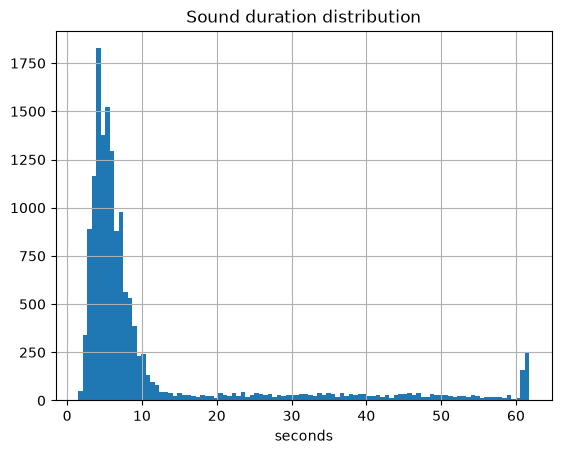

In [8]:
df["sound_duration"].hist(bins=100)
plt.title("Sound duration distribution")
plt.xlabel("seconds")
plt.show()

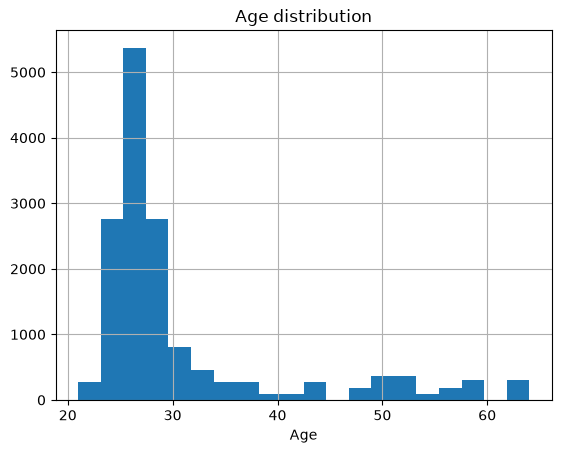

In [9]:
df["age"].hist(bins=20)
plt.title("Age distribution")
plt.xlabel("Age")
plt.show()

C:\Users\arret\AppData\Local\Temp\ipykernel_13456\587708681.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  corr_alc = df[["br_ac","bl_ac"]].corr().iloc[0][1]


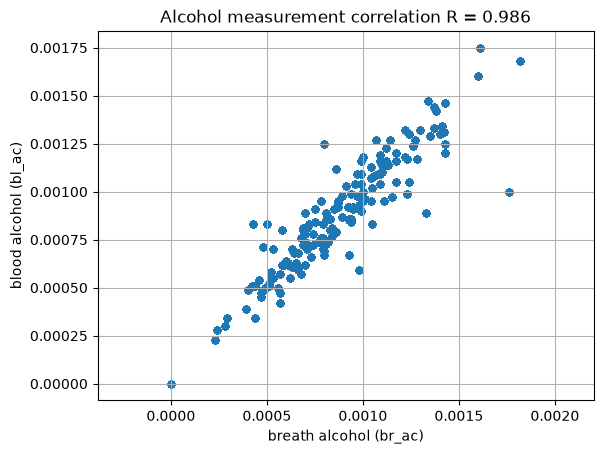

In [10]:
corr_alc = df[["br_ac","bl_ac"]].corr().iloc[0][1]
df.plot.scatter(x="br_ac", y="bl_ac")
plt.title(f"Alcohol measurement correlation R = {corr_alc:.3f}")
plt.axis("equal")
plt.ylabel("blood alcohol (bl_ac)")
plt.xlabel("breath alcohol (br_ac)")
plt.grid()
plt.show()

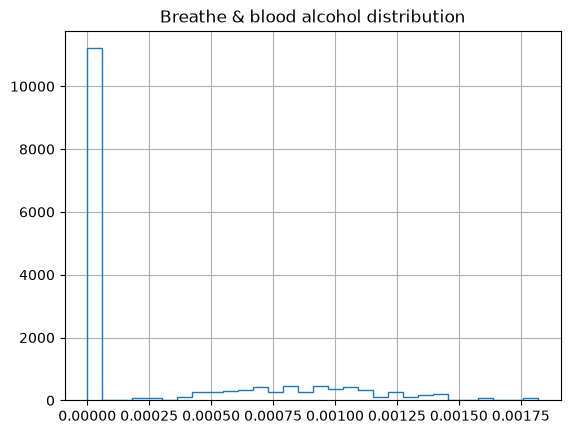

In [ ]:
df[["br_ac","bl_ac"]].hist(density=True, bins=40)
plt.title("Breathe & blood alcohol distribution")
plt.show()

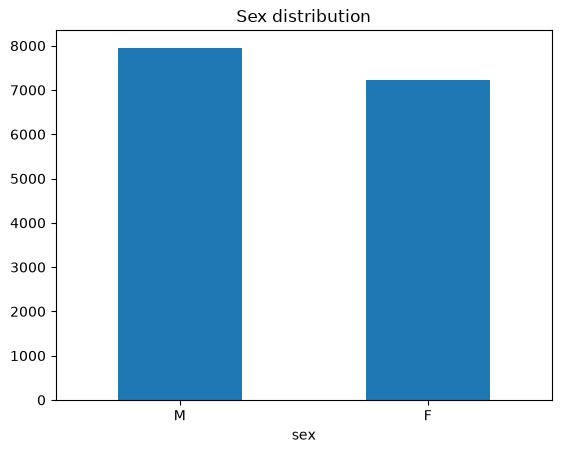

In [32]:
df["sex"].value_counts().plot(kind="bar", rot=0)
plt.title("Sex distribution")
plt.show()

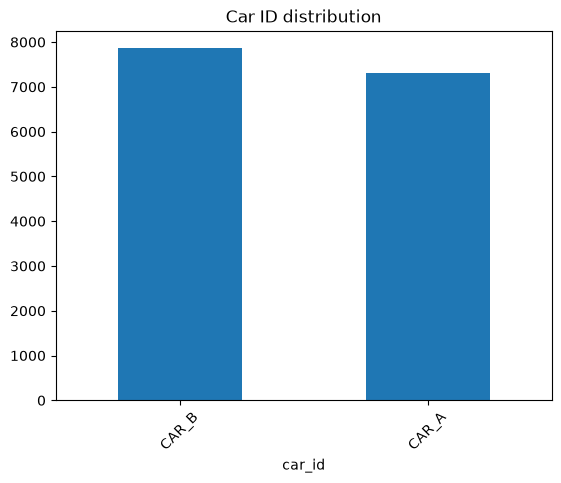

In [18]:
df["car_id"].value_counts().plot(kind="bar", rot=45)
plt.title("Car ID distribution")
plt.show()

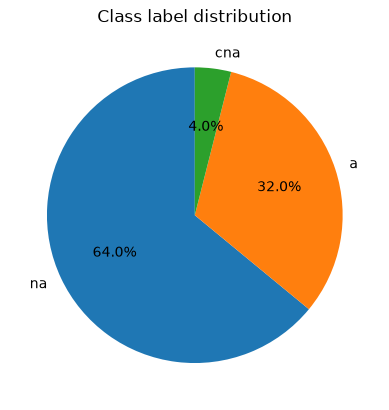

In [48]:
df["class_label"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90, ylabel="")
plt.title("Class label distribution")
plt.show()

In [39]:
print(f"Total: {df["version"].value_counts().sum()}")
df["version"].value_counts()

Total: 15180


version
0    14949
1      213
2       14
3        3
4        1
Name: count, dtype: int64

## CONTENTS.TBL

In [12]:
contents_table = pd.read_table(osp.join(TABLE_DIR,"CONTENTS.TBL"), header=None) # Has no header row
contents_table.nunique()

0    15180
dtype: int64

## SESSEXT.TABL

In [13]:
session_table = pd.read_table(osp.join(TABLE_DIR,"SESSEXT.TBL"))
print(f"Session table shape: {session_table.shape}") # 344 rows = 162*2 + 20
session_table = session_table.rename({
    "SES": "session",
    "AAK": "br-ac", # breath alcohol content
    "BAK": "bl-ac", # blood alcohol content
    "ENV": "car"
})

Session table shape: (344, 14)


In [14]:
session_table.head()

,SES,RED,RET,SCD,AGE,SEX,ACC,REG,ENV,AAK,BAK,GES,CES,WEA
0,1006,2007-11-21,17:32:00,6,26,F,BY,NaN,CAR_B,0.00081,0.00073,f1,r1,SUN
1,1007,2007-11-21,17:54:00,7,25,M,BY,NaN,CAR_B,0.00070,0.00074,f1,r1,SUN
2,1008,2007-11-21,18:14:00,8,29,M,BY,NaN,CAR_B,0.00098,0.00059,f10,r1,SUN
3,1009,2007-11-21,18:33:00,9,26,M,BY,NaN,CAR_B,0.00087,0.00094,f10,r1,SUN
4,3001,2007-11-21,17:23:00,500,25,F,BW,NaN,CAR_A,0.00117,0.00120,f10,r3,SUN


# OpenSmile Feature Extraction

In [20]:
SOUND_FILE_EXAMPLE = osp.join("data","datasnippet","0061006001_h_00.wav")

smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.ComParE_2016,
    feature_level=opensmile.FeatureLevel.Functionals,
)
y = smile.process_file(SOUND_FILE_EXAMPLE)
print(f"Shape: {y.shape}")

Shape: (1, 6373)
